In [ ]:
# ══════════════════════════════════════════════════════════
# Table 2 visual — Grouped Bar Chart (Clean + 4 attacks, 5 models)
# Reads directly from Results_By_Attack.xlsx (uploaded to Colab)
# ══════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── upload the file first in Colab: ──
from google.colab import files
uploaded = files.upload()   # select Results_By_Attack.xlsx when prompted

XLSX_PATH = "Results_By_Attack.xlsx"   # adjust if filename differs after upload

MODEL_NAMES = ['ResNet', 'FCN', 'LSTM', 'LSTM-FCN Vanilla', 'CurAT-LSTM-FCN']
SHEET_MAP = {'Clean': 'clean', 'FGSM': 'fgsm', 'BIM': 'bim', 'PGD': 'pgd', 'CW': 'cw'}

# ── read each sheet, skip title row, use dataset rows only, compute column means ──
averages = {}   # averages['Clean'] = {model: value, ...}

for sheet_name in SHEET_MAP:
    df = pd.read_excel(XLSX_PATH, sheet_name=sheet_name, header=1)  # header=1 skips the title row
    df = df[df['Dataset'].isin([
        'ECG5000','EthanolLevel','FaceAll','FiftyWords','FordA','FordB',
        'MelbournePedestrian','NonInvasiveFetalECGThorax1','PhalangesOutlinesCorrect',
        'ShapesAll','SwedishLeaf','TwoPatterns','ChlorineConcentration',
        'MixedShapesRegularTrain','SemgHandMovementCh2'
    ])]   # keep only the 15 real dataset rows, drop any stray 'Average'/blank rows
    averages[sheet_name] = df[MODEL_NAMES].mean()

# ── Mean-Attack = average of FGSM, BIM, PGD, CW ──
mean_attack = (averages['FGSM'] + averages['BIM'] + averages['PGD'] + averages['CW']) / 4

print("Computed 15-dataset averages:")
for k, v in averages.items():
    print(f"  {k:<6}:", {m: round(v[m], 2) for m in MODEL_NAMES})
print(f"  {'Mean-Attack':<6}:", {m: round(mean_attack[m], 2) for m in MODEL_NAMES})

Saving Results_By_Attack.xlsx to Results_By_Attack.xlsx
Computed 15-dataset averages:
  Clean : {'ResNet': np.float64(86.87), 'FCN': np.float64(85.83), 'LSTM': np.float64(71.08), 'LSTM-FCN Vanilla': np.float64(87.11), 'CurAT-LSTM-FCN': np.float64(80.82)}
  FGSM  : {'ResNet': np.float64(30.64), 'FCN': np.float64(36.31), 'LSTM': np.float64(55.87), 'LSTM-FCN Vanilla': np.float64(40.16), 'CurAT-LSTM-FCN': np.float64(69.07)}
  BIM   : {'ResNet': np.float64(18.82), 'FCN': np.float64(30.61), 'LSTM': np.float64(56.95), 'LSTM-FCN Vanilla': np.float64(33.17), 'CurAT-LSTM-FCN': np.float64(53.31)}
  PGD   : {'ResNet': np.float64(19.56), 'FCN': np.float64(31.09), 'LSTM': np.float64(58.22), 'LSTM-FCN Vanilla': np.float64(34.43), 'CurAT-LSTM-FCN': np.float64(55.22)}
  CW    : {'ResNet': np.float64(11.11), 'FCN': np.float64(53.21), 'LSTM': np.float64(68.03), 'LSTM-FCN Vanilla': np.float64(58.81), 'CurAT-LSTM-FCN': np.float64(69.67)}
  Mean-Attack: {'ResNet': np.float64(20.03), 'FCN': np.float64(37.81)

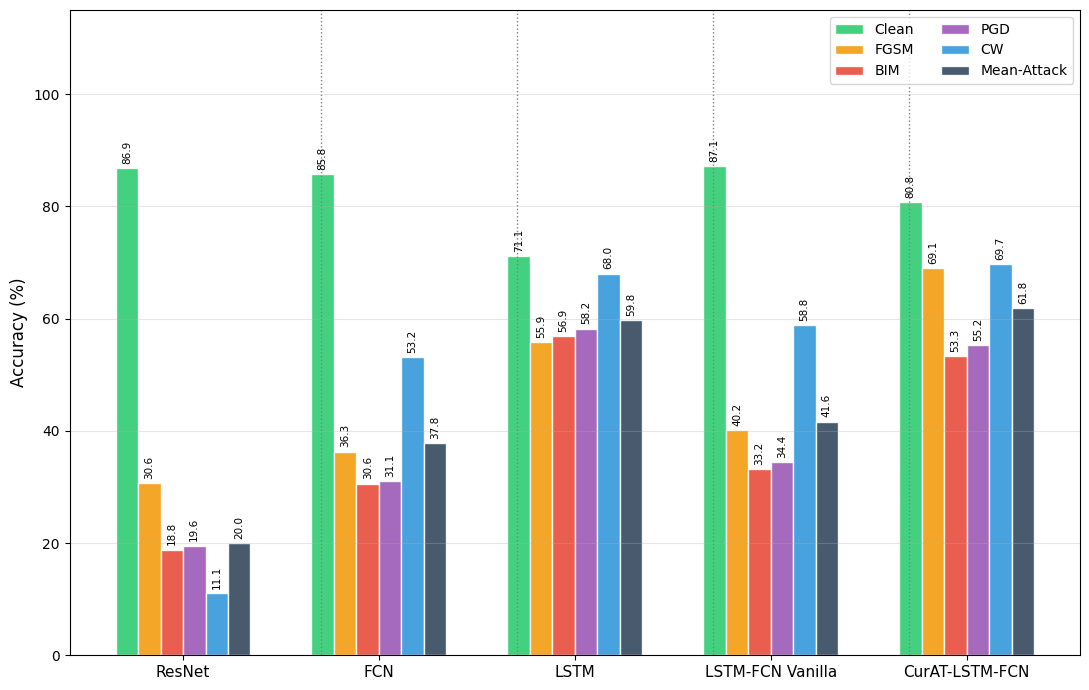

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
metrics      = ['Clean', 'FGSM', 'BIM', 'PGD', 'CW', 'Mean-Attack']
metric_data  = [averages['Clean'], averages['FGSM'], averages['BIM'],
                 averages['PGD'], averages['CW'], mean_attack]
bar_colors   = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#3498db', '#34495e']

fig, ax = plt.subplots(figsize=(11, 7))
n_bars = len(metrics)
x      = np.arange(len(MODEL_NAMES)) * (n_bars + 0.1)
width  = 0.7

for i, (metric_name, data, color) in enumerate(zip(metrics, metric_data, bar_colors)):
    vals = [data[m] for m in MODEL_NAMES]
    bars = ax.bar(x + i * width, vals, width, label=metric_name,
                   color=color, edgecolor='white', alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.annotate(f'{v:.1f}', xy=(bar.get_x() + bar.get_width() / 2, v),
                     xytext=(0, 3), textcoords='offset points',
                     ha='center', va='bottom', fontsize=7.5, rotation=90)

ax.set_xticks(x + width * (n_bars - 1) / 2)
ax.set_xticklabels(MODEL_NAMES, fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_ylim(0, 115)
ax.legend(fontsize=10, ncol=2, loc='upper right')
ax.grid(axis='y', alpha=0.3)
for xi in x[1:]:
    ax.axvline(xi - 0.05, color='gray', ls=':', lw=1.0)

plt.tight_layout()
plt.savefig("table2_overall_performance.png", dpi=300, bbox_inches='tight')
plt.show()

files.download("table2_overall_performance.png")

Saving Results_By_Attack.xlsx to Results_By_Attack (1).xlsx


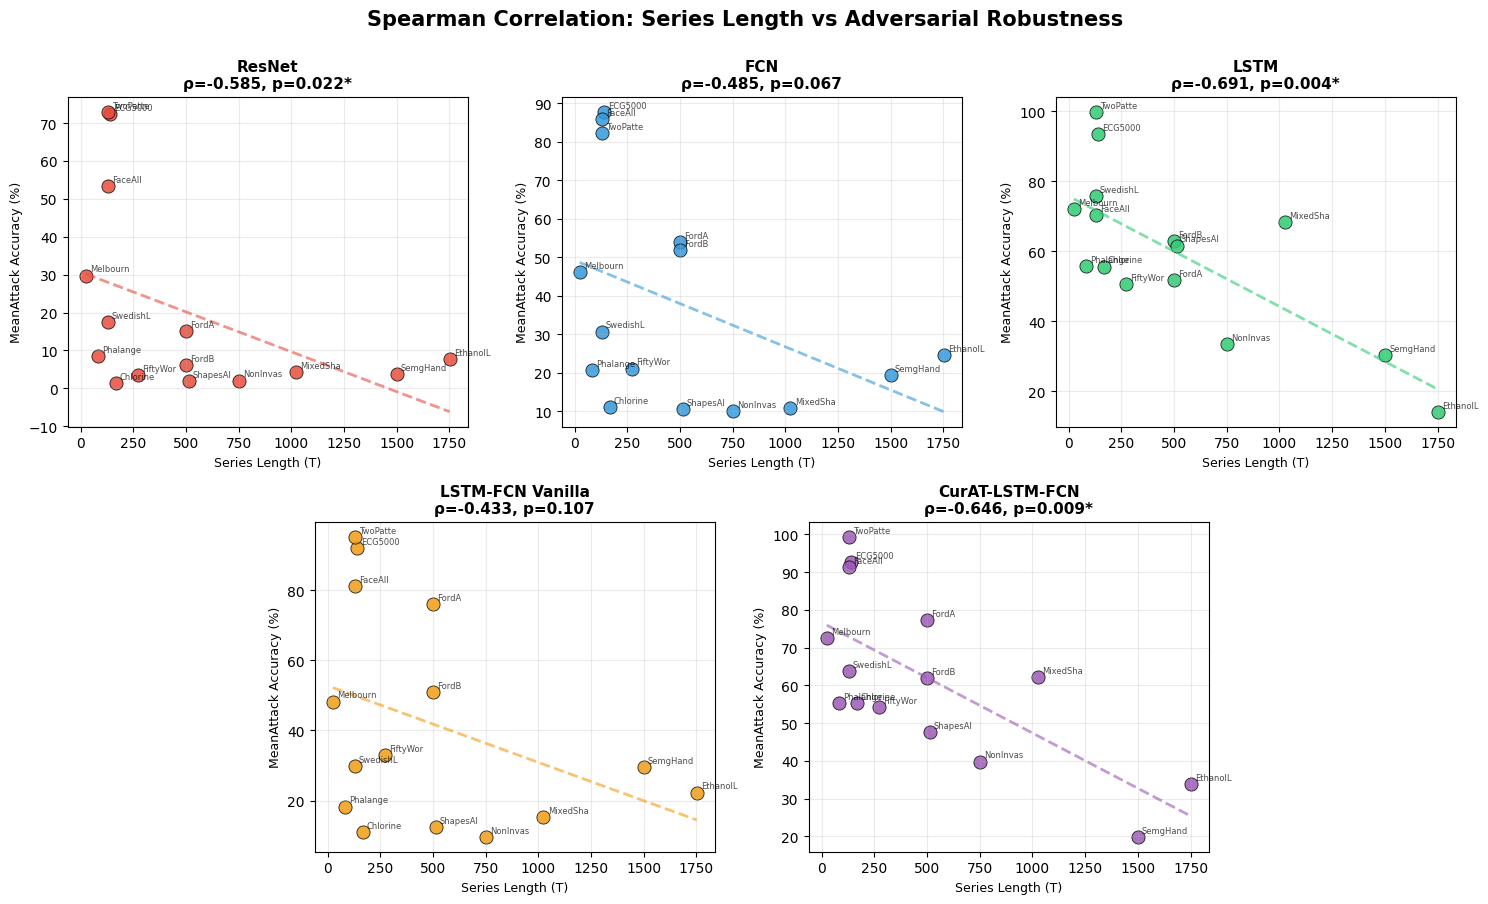

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Saved: spearman_correlation_5models.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from google.colab import files

uploaded = files.upload()   # ← attach Results_By_Attack.xlsx yahan

XLSX_PATH = "Results_By_Attack.xlsx"

DATASETS = ['ECG5000','EthanolLevel','FaceAll','FiftyWords','FordA','FordB',
            'MelbournePedestrian','NonInvasiveFetalECGThorax1','PhalangesOutlinesCorrect',
            'ShapesAll','SwedishLeaf','TwoPatterns','ChlorineConcentration',
            'MixedShapesRegularTrain','SemgHandMovementCh2']

MODEL_NAMES = ['ResNet', 'FCN', 'LSTM', 'LSTM-FCN Vanilla', 'CurAT-LSTM-FCN']

# ── verified series-lengths, UCR archive official values ──
SERIES_LENGTH = {
    'ECG5000': 140, 'EthanolLevel': 1751, 'FaceAll': 131, 'FiftyWords': 270,
    'FordA': 500, 'FordB': 500, 'MelbournePedestrian': 24,
    'NonInvasiveFetalECGThorax1': 750, 'PhalangesOutlinesCorrect': 80,
    'ShapesAll': 512, 'SwedishLeaf': 128, 'TwoPatterns': 128,
    'ChlorineConcentration': 166, 'MixedShapesRegularTrain': 1024,
    'SemgHandMovementCh2': 1500
}

# ── compute per-model MeanAttack accuracy from the 4 attack sheets ──
ATTACKS = ['FGSM', 'BIM', 'PGD', 'CW']
sheets = {}
for name in ATTACKS:
    df = pd.read_excel(XLSX_PATH, sheet_name=name, header=1)
    df = df[df['Dataset'].isin(DATASETS)].set_index('Dataset')
    sheets[name] = df

mean_attack_by_model = {}
for model in MODEL_NAMES:
    mean_attack_by_model[model] = {
        ds: np.mean([sheets[atk].loc[ds, model] for atk in ATTACKS])
        for ds in DATASETS
    }

T_vals_all = [SERIES_LENGTH[ds] for ds in DATASETS]

# ══════════════════════════════════════════════════════════
# Plot — GridSpec, bottom row centered
# ══════════════════════════════════════════════════════════

fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(2, 6, figure=fig)

ax_positions = [gs[0,0:2], gs[0,2:4], gs[0,4:6], gs[1,1:3], gs[1,3:5]]
axes = [fig.add_subplot(pos) for pos in ax_positions]

fig.suptitle("Spearman Correlation: Series Length vs Adversarial Robustness",
             fontsize=15, fontweight='bold', y=1.00)

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for ax, model, color in zip(axes, MODEL_NAMES, colors):
    acc_vals = [mean_attack_by_model[model][ds] for ds in DATASETS]

    rho, pval = spearmanr(T_vals_all, acc_vals)
    sig = "*" if pval < 0.05 else ""

    ax.scatter(T_vals_all, acc_vals, color=color, s=90, alpha=0.85, edgecolor='black', linewidth=0.6)

    z = np.polyfit(T_vals_all, acc_vals, 1)
    xs = np.linspace(min(T_vals_all), max(T_vals_all), 100)
    ax.plot(xs, np.polyval(z, xs), '--', color=color, alpha=0.6, linewidth=2)

    for ds, t, a in zip(DATASETS, T_vals_all, acc_vals):
        ax.annotate(ds[:8], (t, a), fontsize=6, alpha=0.7, xytext=(3,3), textcoords='offset points')

    ax.set_title(f"{model}\nρ={rho:.3f}, p={pval:.3f}{sig}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Series Length (T)", fontsize=9)
    ax.set_ylabel("MeanAttack Accuracy (%)", fontsize=9)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("spearman_correlation_5models.png", dpi=300, bbox_inches='tight')
plt.show()

files.download("spearman_correlation_5models.png")
print("✓ Saved: spearman_correlation_5models.png")

Saving Results_By_Attack.xlsx to Results_By_Attack (1).xlsx


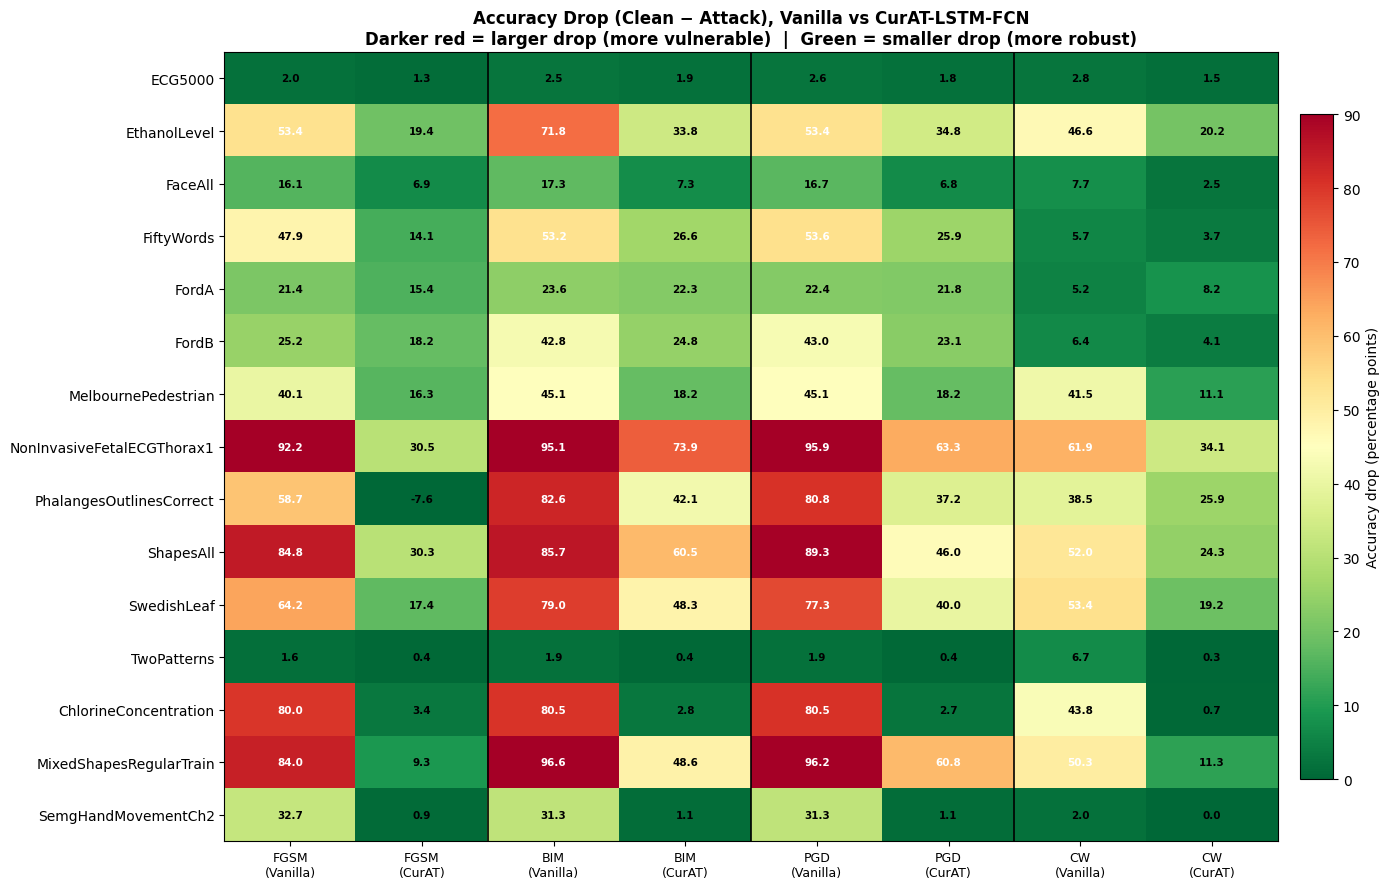

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Saved and downloading: graph2_dropheatmap_vanilla_vs_curat.png


In [ ]:
# ══════════════════════════════════════════════════════════
# Graph 2 — Accuracy-Drop Heatmap: Vanilla vs CurAT, side-by-side
# 15 datasets × 4 attacks × 2 models
# ══════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()   # select Results_By_Attack.xlsx

XLSX_PATH = "Results_By_Attack.xlsx"

DATASETS = ['ECG5000','EthanolLevel','FaceAll','FiftyWords','FordA','FordB',
            'MelbournePedestrian','NonInvasiveFetalECGThorax1','PhalangesOutlinesCorrect',
            'ShapesAll','SwedishLeaf','TwoPatterns','ChlorineConcentration',
            'MixedShapesRegularTrain','SemgHandMovementCh2']

ATTACKS = ['FGSM', 'BIM', 'PGD', 'CW']

# ── load each sheet, index by dataset ──
sheets = {}
for name in ['Clean'] + ATTACKS:
    df = pd.read_excel(XLSX_PATH, sheet_name=name, header=1)
    df = df[df['Dataset'].isin(DATASETS)].set_index('Dataset')
    sheets[name] = df

# ── build drop matrices: drop = clean - attack_accuracy ──
vanilla_drop = np.zeros((len(DATASETS), len(ATTACKS)))
curat_drop   = np.zeros((len(DATASETS), len(ATTACKS)))

for i, ds in enumerate(DATASETS):
    clean_v = sheets['Clean'].loc[ds, 'LSTM-FCN Vanilla']
    clean_c = sheets['Clean'].loc[ds, 'CurAT-LSTM-FCN']
    for j, atk in enumerate(ATTACKS):
        vanilla_drop[i, j] = clean_v - sheets[atk].loc[ds, 'LSTM-FCN Vanilla']
        curat_drop[i, j]   = clean_c - sheets[atk].loc[ds, 'CurAT-LSTM-FCN']

# ── interleave into one side-by-side matrix: [V-FGSM, C-FGSM, V-BIM, C-BIM, ...] ──
combined = np.zeros((len(DATASETS), len(ATTACKS) * 2))
col_labels = []
for j, atk in enumerate(ATTACKS):
    combined[:, 2*j]   = vanilla_drop[:, j]
    combined[:, 2*j+1] = curat_drop[:, j]
    col_labels += [f"{atk}\n(Vanilla)", f"{atk}\n(CurAT)"]

# ══════════════════════════════════════════════════════════
# Plot
# ══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 9))
im = ax.imshow(combined, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=90)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=9)
ax.set_yticks(range(len(DATASETS)))
ax.set_yticklabels(DATASETS, fontsize=10)

ax.set_title("Accuracy Drop (Clean − Attack), Vanilla vs CurAT-LSTM-FCN\n"
             "Darker red = larger drop (more vulnerable)  |  Green = smaller drop (more robust)",
             fontsize=12, fontweight='bold')

# annotate each cell
for i in range(len(DATASETS)):
    for j in range(len(ATTACKS) * 2):
        val = combined[i, j]
        ax.text(j, i, f"{val:.1f}", ha='center', va='center',
                 fontsize=7.5, fontweight='bold',
                 color='white' if val > 50 else 'black')

# separators between attack-pairs for readability
for j in range(2, len(col_labels), 2):
    ax.axvline(j - 0.5, color='black', lw=1.2)

plt.colorbar(im, ax=ax, label='Accuracy drop (percentage points)', fraction=0.03, pad=0.02)
plt.tight_layout()
plt.savefig("graph2_dropheatmap_vanilla_vs_curat.png", dpi=300, bbox_inches='tight')
plt.show()

files.download("graph2_dropheatmap_vanilla_vs_curat.png")
print("✓ Saved and downloading: graph2_dropheatmap_vanilla_vs_curat.png")

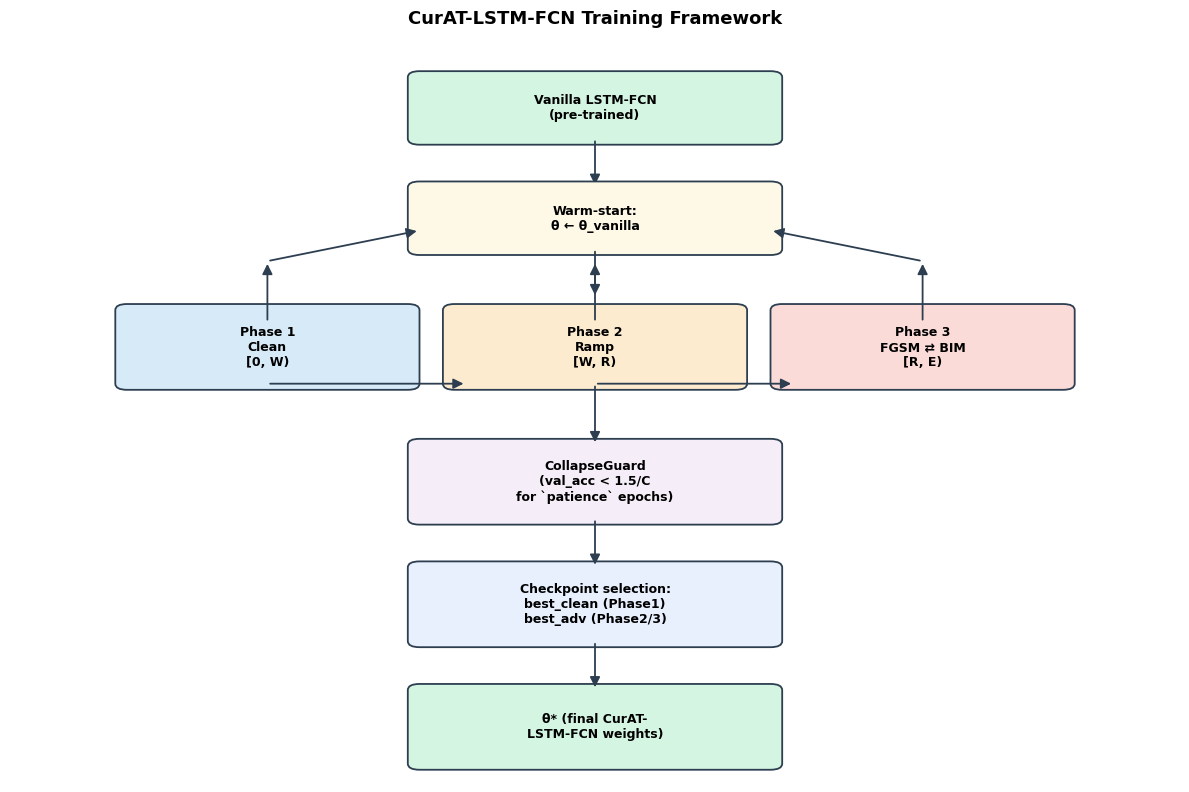

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Saved and downloading: framework_flowchart.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 10); ax.set_ylim(0, 12); ax.axis('off')

def box(x, y, w, h, text, color='#e8f0fe', fontsize=9):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                        facecolor=color, edgecolor='#2c3e50', linewidth=1.3)
    ax.add_patch(b)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=fontsize,
             fontweight='bold', wrap=True)

def arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>',
                 mutation_scale=15, color='#2c3e50', linewidth=1.3))

box(3.5, 10.5, 3, 1, "Vanilla LSTM-FCN\n(pre-trained)", '#d5f5e3')
arrow(5, 10.5, 5, 9.7)
box(3.5, 8.7, 3, 1, "Warm-start:\nθ ← θ_vanilla", '#fef9e7')
arrow(5, 8.7, 5, 7.9)
box(1, 6.5, 2.4, 1.2, "Phase 1\nClean\n[0, W)", '#d6eaf8')
box(3.8, 6.5, 2.4, 1.2, "Phase 2\nRamp\n[W, R)", '#fdebd0')
box(6.6, 6.5, 2.4, 1.2, "Phase 3\nFGSM ⇄ BIM\n[R, E)", '#fadbd8')
arrow(2.2, 7.5, 2.2, 8.5); arrow(2.2, 8.5, 3.5, 9)
arrow(5, 7.5, 5, 8.5)
arrow(7.8, 7.5, 7.8, 8.5); arrow(7.8, 8.5, 6.5, 9)
arrow(2.2, 6.5, 3.9, 6.5); arrow(5, 6.5, 6.7, 6.5)
box(3.5, 4.3, 3, 1.2, "CollapseGuard\n(val_acc < 1.5/C\nfor `patience` epochs)", '#f5eef8')
arrow(5, 6.5, 5, 5.5)
box(3.5, 2.3, 3, 1.2, "Checkpoint selection:\nbest_clean (Phase1)\nbest_adv (Phase2/3)", '#e8f0fe')
arrow(5, 4.3, 5, 3.5)
box(3.5, 0.3, 3, 1.2, "θ* (final CurAT-\nLSTM-FCN weights)", '#d5f5e3')
arrow(5, 2.3, 5, 1.5)

ax.set_title("CurAT-LSTM-FCN Training Framework", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("framework_flowchart.png", dpi=300, bbox_inches='tight')
plt.show()

# ── download ──
from google.colab import files
files.download("framework_flowchart.png")
print("✓ Saved and downloading: framework_flowchart.png")

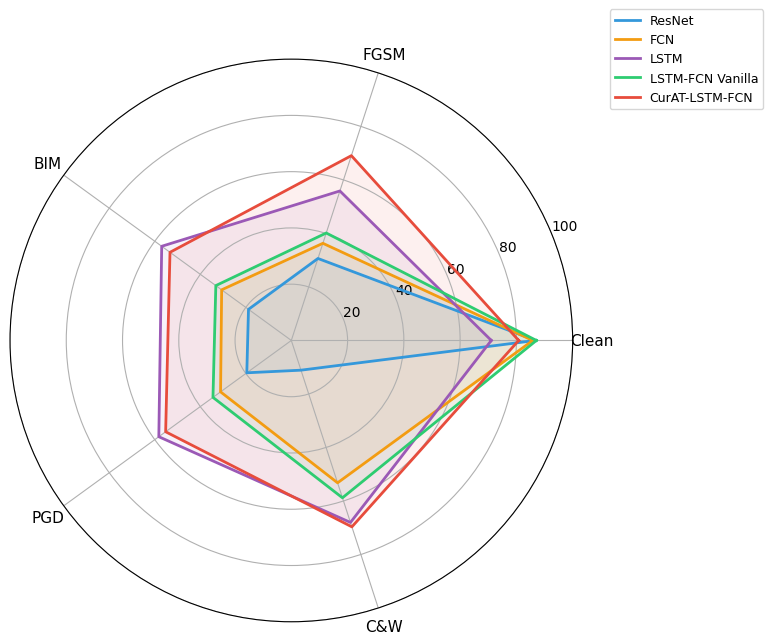

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Saved and downloading: radar_chart_table2.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ['Clean', 'FGSM', 'BIM', 'PGD', 'C&W']
data = {
    'ResNet':           [86.87, 30.64, 18.82, 19.56, 11.11],
    'FCN':              [85.83, 36.31, 30.61, 31.09, 53.21],
    'LSTM':             [71.08, 55.87, 56.95, 58.22, 68.03],
    'LSTM-FCN Vanilla': [87.11, 40.16, 33.17, 34.43, 58.81],
    'CurAT-LSTM-FCN':   [80.82, 69.07, 53.31, 55.22, 69.67],
}
colors = {'ResNet':'#3498db','FCN':'#f39c12','LSTM':'#9b59b6',
          'LSTM-FCN Vanilla':'#2ecc71','CurAT-LSTM-FCN':'#e74c3c'}

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for model, vals in data.items():
    vals_c = vals + vals[:1]
    ax.plot(angles, vals_c, linewidth=2, label=model, color=colors[model])
    ax.fill(angles, vals_c, alpha=0.08, color=colors[model])

ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 100)

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig("radar_chart_table2.png", dpi=300, bbox_inches='tight')
plt.show()

# ── download ──
from google.colab import files
files.download("radar_chart_table2.png")
print("✓ Saved and downloading: radar_chart_table2.png")

Saving Statistical_Results.xlsx to Statistical_Results (6).xlsx


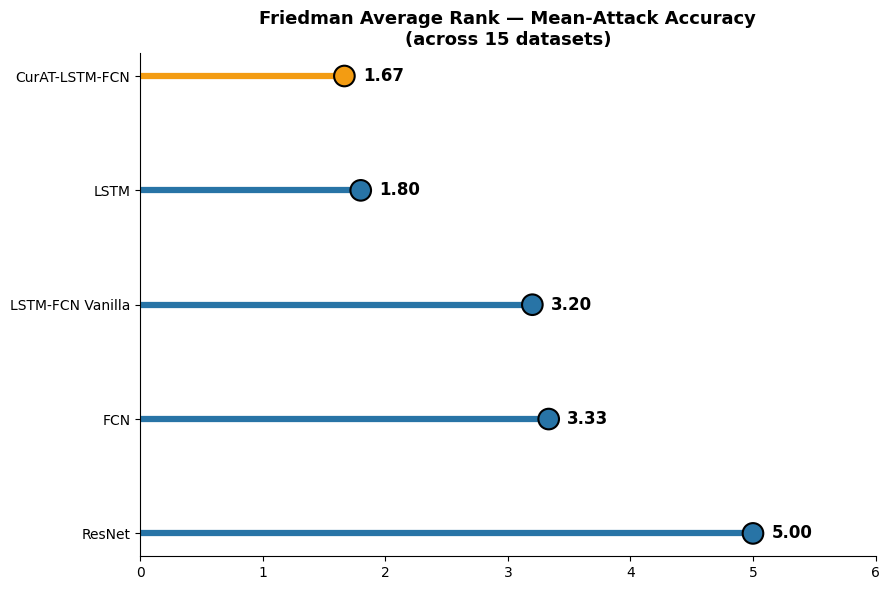

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Saved: graph3_lollipop.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
avg_rank = pd.read_excel("Statistical_Results.xlsx", sheet_name='Average_Rank')
sub = avg_rank[avg_rank['Sheet']=='MeanAttack'].sort_values('Average_Rank', ascending=False)
models, ranks = sub['Model'].tolist(), sub['Average_Rank'].tolist()

colors = ['#f39c12' if m=='CurAT-LSTM-FCN' else '#2874a6' for m in models]

fig, ax = plt.subplots(figsize=(9, 6))
ax.hlines(y=models, xmin=0, xmax=ranks, color=colors, linewidth=4.5)
ax.scatter(ranks, models, color=colors, s=220, zorder=3, edgecolor='black', linewidth=1.5)
for i, (m, v) in enumerate(zip(models, ranks)):
    ax.text(v+0.15, i, f'{v:.2f}', va='center', fontsize=12, fontweight='bold')

ax.set_title("Friedman Average Rank — Mean-Attack Accuracy\n(across 15 datasets)",
              fontsize=13, fontweight='bold')
ax.set_xlim(0, max(ranks)+1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("graph3_lollipop.png", dpi=300, bbox_inches='tight')
plt.show()

files.download("graph3_lollipop.png")
print("✓ Saved: graph3_lollipop.png")